In [2]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Projects/bee_5850/hw02-britols`


### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [3]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Optim # optimization tools

### The Energy Balance Model (EBM)

$$\frac{dH}{dt} = F - \lambda T$$
$$C\frac{dT}{dt} = F - \lambda T - \gamma(T-T_D)$$
$$C_D\frac{dT_D}{dt} = \gamma(T-T_D)$$


In [4]:
temps = CSV.read("data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv", DataFrame, delim=",")
temps = temps[temps.Time .< 2023,: ];

time_obs = temps[:, 1];
temp_obs = temps[:, 2];
temp_lo = temps[:, 3];
temp_hi = temps[:, 4];

temp_lo = temp_lo .- mean(temp_obs[1:20]);
temp_hi = temp_hi .- mean(temp_obs[1:20]);
temp_obs = temp_obs .- mean(temp_obs[1:20]); # compute anomalies relative to first 20 years of data
temp_sd = (temp_hi - temp_lo) / 1.96; # estimate standard deviation using 95% CI

# generate simulations
hind_years = 1850:2022; # model years to simulate for fitting
sim_years = 1850:2100; # model years for projections
forcing_years = 1750:2500; # years for which we have forcing data/simulations
hind_idx = indexin(hind_years, forcing_years); # find indices in t vector of simulation years
sim_idx = indexin(sim_years, forcing_years);

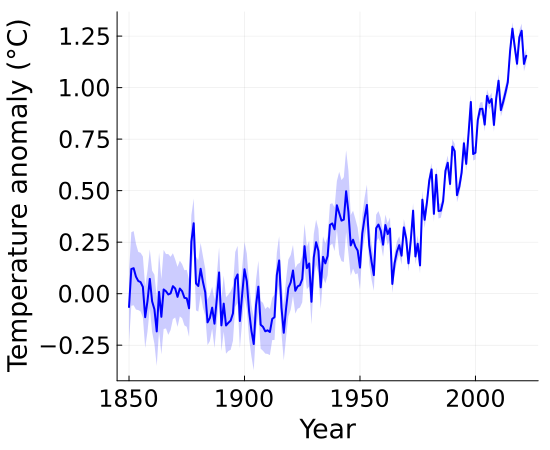

In [5]:
plot(time_obs, temp_obs, ribbon=(temp_obs-temp_lo,temp_hi-temp_obs), color="blue", linewidth=2, fillalpha=0.2, legend=false, xlabel="Year", ylabel="Temperature anomaly (°C)", labelfontsize=18, tickfontsize=16)
plot!(size=(550, 450))

In [6]:
# Dataset from https://zenodo.org/record/3973015
# The CSV is read into a DataFrame object, and we specify that it is comma delimited
forcings_all_85 = CSV.read("data/ERF_ssp585_1750-2500.csv", DataFrame, delim=",");

# Separate out the individual components
forcing_co2_85 = forcings_all_85[!,"co2"];
# Get total aerosol forcings
forcing_aerosol_rad_85 = forcings_all_85[!,"aerosol-radiation_interactions"];
forcing_aerosol_cloud_85 = forcings_all_85[!,"aerosol-cloud_interactions"];
forcing_aerosol_85 = forcing_aerosol_rad_85 + forcing_aerosol_cloud_85;
forcing_total_85 = forcings_all_85[!,"total"];
forcing_non_aerosol_85 = forcing_total_85 - forcing_aerosol_85;
forcing_other_85 = forcing_total_85 - (forcing_co2_85 + forcing_aerosol_85);

t = time_forcing = Int64.(forcings_all_85[!,"year"]); # Ensure that years are interpreted as integers

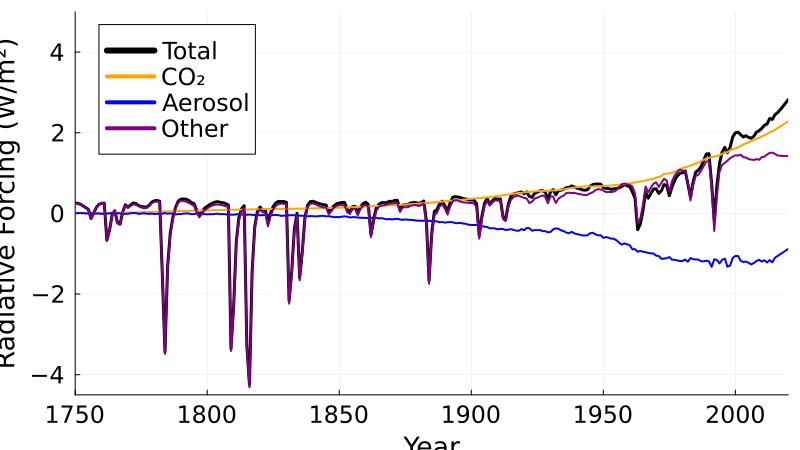

In [7]:
plot(xlabel="Year", ylabel="Radiative Forcing (W/m²)", tickfontsize=16, guidefontsize=18, legendfontsize=16)
plot!(time_forcing, forcing_total_85, label="Total", color=:black, linewidth=3)
plot!(time_forcing, forcing_co2_85, label="CO₂", color=:orange, linewidth=2)
plot!(time_forcing, forcing_aerosol_85, label="Aerosol", color=:blue, linewidth=2)
plot!(time_forcing, forcing_other_85, label="Other", color=:purple, linewidth=2)
plot!(size=(800, 450))
xlims!((1750, 2020))
ylims!(-4.5,5)

### EBM Discretization

$$T(t+1) = T(t) + \frac{F(t) - \lambda T(t)-\gamma(T(t)-T_D(d))}{C}\Delta t$$
$$T_D(t+1) = T_D(t) + \frac{\gamma(T(t)-T_D(t))}{C_D}\Delta t$$

When dT/dt = 0 and F constant

$$T = \frac{F}{\lambda}$$

### Free parameters

- $\lambda$ or S
- $\gamma$ (deep ocean temp diffusion)
- $\alpha$ (aerosol scale factor)
- d (upper ocean mixing depth)
- D (deep ocean mixing depth)
- T₀(initial temperature in 1850)

In [8]:
function ebm(rf_nonaerosol, rf_aerosol; p=(3.2, 1.0, 1.3, 100.0, 800.0, -0.1))
    # set up model parameters
    S, γ, α, d, D, T₀ = p # this unpacks the parameter tuple into variables
    F2xCO₂ = 4.0 # radiative forcing [W/m²] for a doubling of CO₂
    λ = F2xCO₂ / S

    c = 4.184e6 # heat capacity/area [J/K/m²]
    C = c*d # heat capacity of mixed layer (per area)
    CD = c*D # heat capacity of deep layer (per area)
    F = rf_nonaerosol + α*rf_aerosol # radiative forcing
    Δt = 31558152. # annual timestep [s]

    T = zero(F)
    T[1] = T₀
    TD = zero(F)
    for i in 1:length(F)-1
        T[i+1] = T[i] + (F[i] - λ*T[i] - γ*(T[i]-TD[i]))/C * Δt
        TD[i+1] = TD[i] + γ*(T[i]-TD[i])/CD * Δt
    end
    # return after normalizing to reference period
    return T
end

ebm_wrap(params) = ebm(forcing_non_aerosol_85[hind_idx], forcing_aerosol_85[hind_idx], p = params)

ebm_wrap (generic function with 1 method)

### Assuming Gaussian Discrepancy

$$y = \eta(x;\theta) + \delta(x) + \epsilon$$
$$\delta \sim N(0,\sigma^2)$$
$$\epsilon \sim N(0,\omega^2)$$

x control variables

$\theta$ calibration variables

where $\omega$ is the standard error of the data

In [9]:
function gaussian_iid_homosked(params, temp_dat, temp_err, m)
    S, γ, α, d, D, T₀, σ = params 
    ebm_sim = m((S, γ, α, d, D, T₀))
    ll = sum(logpdf.(Normal.(ebm_sim, sqrt.(σ^2 .+ temp_err.^2)), temp_dat))
    return ll
end

lower = [1.0, 0.5, 0.0, 50.0, 200.0, temp_lo[1], 0.0]
upper = [5.0, 1.5, 2.0, 200.0, 1000.0, temp_hi[1], 10.0]
p0 = [3.0, 1.0, 1.0, 100.0, 800.0,temp_obs[1], 5.0]


result = Optim.optimize(params -> -gaussian_iid_homosked(params, temp_obs, temp_sd, ebm_wrap), lower, upper, p0)
θ_iid = result.minimizer

7-element Vector{Float64}:
   3.3970948493835857
   1.4999999999999998
   0.9449472510105004
  80.33764224202443
 621.9226932891894
  -0.15357013670023517
   0.09135325827164065

| Parameters    | MLE |
| -------- | ------- |
| S  | 3.4    |
| $\gamma$ | 1.5    |
| $\alpha$    | 0.94    |
| d    | 80.3    |
| D    | 621   |
| T₀    | -0.15   |
| $\sigma$    | 0.09    |

In [24]:
length(temp_sd)

173

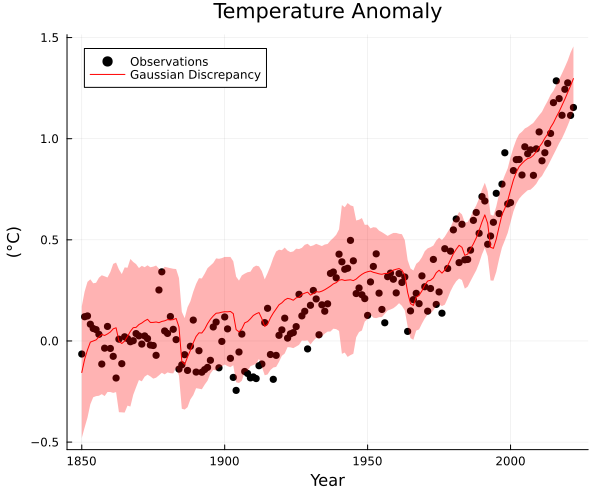

In [10]:
n_samples = 10_000
temp_iid = ebm_wrap(θ_iid) # simulate IID best fit
# simulate projections with discrepancy and errors
temp_iid_proj = zeros(n_samples, length(temp_sd))
for i = 1:length(temp_sd)
    temp_iid_err = rand(Normal(0, sqrt.(θ_iid[end]^2 .+ temp_sd[i]^2)), n_samples)
    temp_iid_proj[:, i] = temp_iid[i] .+ temp_iid_err
end
# calculate quantiles
temp_iid_q = mapslices(col -> quantile(col, [0.05, 0.5, 0.95]), temp_iid_proj; dims=1)

p = scatter(time_obs, temp_obs, color=:black, label="Observations", ylabel="(°C)", xlabel="Year", title="Temperature Anomaly")
plot!(p, time_obs, temp_iid_q[2, :], ribbon=(temp_iid_q[2, :] - temp_iid_q[1, :], temp_iid_q[3, :] - temp_iid_q[2, :]), color=:red, fillalpha=0.3, label="Gaussian Discrepancy")
plot!(size=(600, 500))

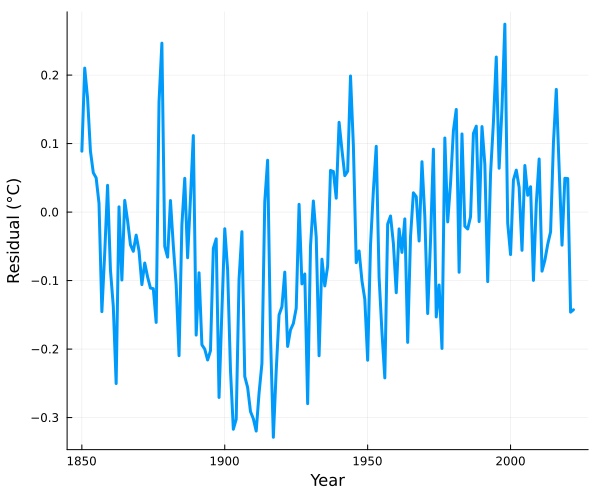

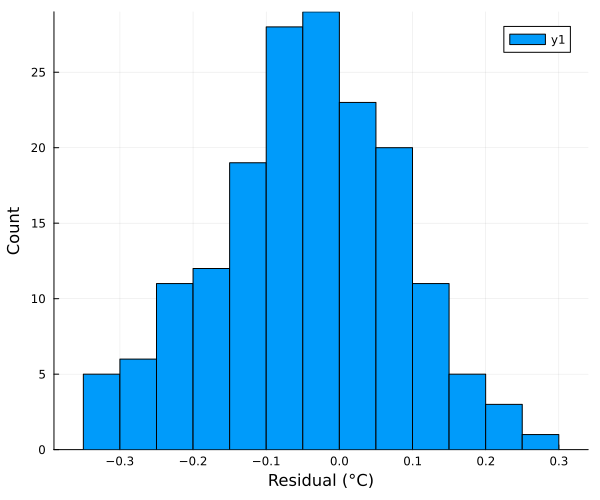

In [11]:
resids_homogauss = temp_obs - temp_iid
p1 = plot(time_obs, resids_homogauss, linewidth=3, label=false, size=(600, 500), xlabel="Year", ylabel="Residual (°C)")
p2 = histogram(resids_homogauss, size=(600, 500), xlabel="Residual (°C)", ylabel="Count")

display(p1)
display(p2)

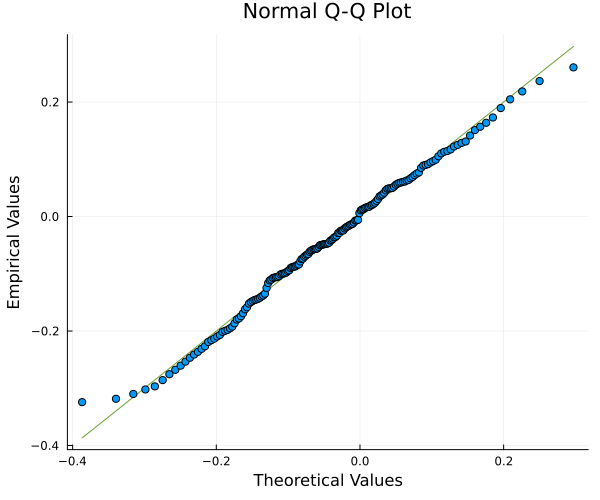

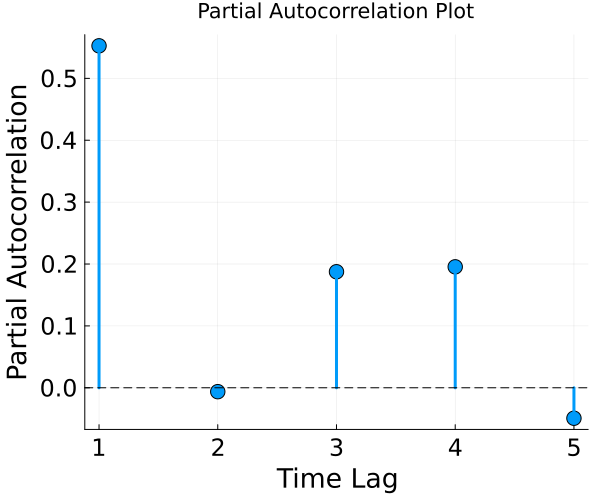

In [12]:
p1 = qqnorm(resids_homogauss, xlabel="Theoretical Values", ylabel="Empirical Values", title="Normal Q-Q Plot", size=(600, 500))
pacf_homogauss = pacf(resids_homogauss, 1:5)
p2 = plot(1:5, pacf_homogauss, marker=:circle, line=:stem, linewidth=3, markersize=8, tickfontsize=16, guidefontsize=18, legend=false, ylabel="Partial Autocorrelation", xlabel="Time Lag", title="Partial Autocorrelation Plot", size=(600, 500))
hline!(p2, [0], color=:black, linestyle=:dash)

display(p1)
display(p2)

### AR(1)

In [13]:
# temp_obs: temperature data
# temp_err: standard deviations for temperatures
# m: model function
function ar_loglik(params, temp_obs, temp_err, m)
    S, γ, α, d, D, T₀, ρ, σ = params 
    ebm_sim = m((S, γ, α, d, D, T₀))
    residuals = temp_obs - ebm_sim
    # whiten residuals
    ll = 0
    # notice addition of observation errors
    for t = 1:length(temp_sd)
        if t == 1
            ll += logpdf(Normal(0, sqrt(σ^2 / (1 - ρ^2) + temp_err[1]^2)), residuals[1])
        else
            resid_wn = residuals[t] - ρ * residuals[t-1]
            ll += logpdf(Normal(0, sqrt(σ^2 + temp_err[t]^2)), resid_wn)
        end
    end
    return ll
end

ar_loglik (generic function with 1 method)

In [14]:
lower = [1.0, 0.5, 0.0, 50.0, 200.0, temp_lo[1], -1.0, 0.0]
upper = [5.0, 1.5, 2.0, 200.0, 1000.0, temp_hi[1], 1.0, 10.0]
p0 = [3.0, 1.0, 1.0, 100.0, 800.0,temp_obs[1], 0.0, 5.0]

result = Optim.optimize(params -> -ar_loglik(params, temp_obs, temp_sd, ebm_wrap), lower, upper, p0)
θ_ar = result.minimizer

8-element Vector{Float64}:
   3.2556063232744625
   1.4999999999981868
   0.892201066103411
  91.15856602204401
 647.2150601343391
  -0.12264996607748373
   0.517605645782455
   0.08047109749642153

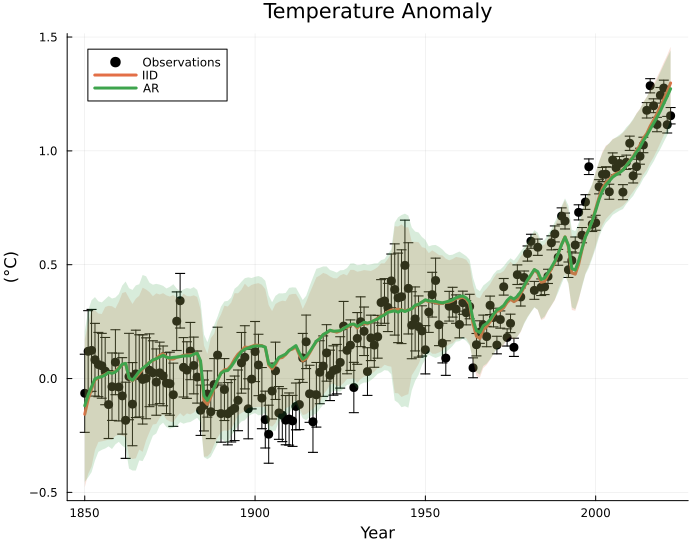

In [15]:
n = 10_000

# get model hindcasts
temp_iid = ebm_wrap(θ_iid[1:end-1])
temp_ar = ebm_wrap(θ_ar[1:end-2])

# get iid and AR residuals from relevant processes
residuals_iid = stack(rand.(Normal.(0, sqrt.(temp_sd.^2 .+ θ_iid[end].^2)), n), dims=1)
residuals_ar = zeros(length(hind_idx), n)
for t = 1:length(temp_sd)
    if t == 1
        residuals_ar[t, :] = rand(Normal(0, sqrt(θ_ar[end]^2 / (1 - θ_ar[end-1]^2) + temp_sd[1]^2)), n)
    else
        residuals_ar[t, :] = θ_ar[end-1] * residuals_ar[t-1, :] + rand(Normal(0, sqrt(θ_ar[end]^2 + temp_sd[t]^2)), n)
    end
end

# add residuals back to model simulations
model_sim_iid = (residuals_iid .+ temp_iid)'
model_sim_ar = (residuals_ar .+ temp_ar)'

# get quantiles
q90_iid = mapslices(col -> quantile(col, [0.05, 0.5, 0.95]), model_sim_iid; dims=1) # compute 90% prediction interval
q90_ar = mapslices(col -> quantile(col, [0.05, 0.5, 0.95]), model_sim_ar; dims=1) # compute 90% prediction interval

p = scatter(time_obs, temp_obs, yerr=(temp_obs - temp_lo, temp_hi - temp_obs), color=:black, label="Observations", ylabel="(°C)", xlabel="Year", title="Temperature Anomaly", markersize=5)
plot!(p, hind_years, q90_iid[2, :], ribbon=(q90_iid[2, :] - q90_iid[1, :], q90_iid[3, :] - q90_iid[2, :]), fillalpha=0.2, linewidth=3, label="IID")
plot!(p, hind_years, q90_ar[2, :], ribbon=(q90_ar[2, :] - q90_ar[1, :], q90_ar[3, :] - q90_ar[2, :]), fillalpha=0.2, linewidth=3, label="AR")
plot!(size=(700, 550))

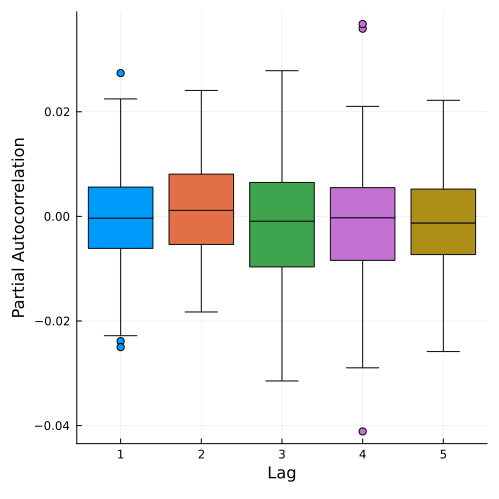

In [16]:
resids_ar_sim = model_sim_ar .- temp_obs'
boxplot(mapslices(col -> pacf(col, 1:5), resids_ar_sim; dims=1)', label=:false, xlabel="Lag", ylabel="Partial Autocorrelation")
plot!(size=(500, 500))

In [17]:
# Dataset from https://zenodo.org/record/3973015
# The CSV is read into a DataFrame object, and we specify that it is comma delimited
forcings_all_26 = CSV.read("data/ERF_ssp126_1750-2500.csv", DataFrame, delim=",")

# Separate out the individual components
forcing_co2_26 = forcings_all_26[!,"co2"]
# Get total aerosol forcings
forcing_aerosol_rad_26 = forcings_all_26[!,"aerosol-radiation_interactions"]
forcing_aerosol_cloud_26 = forcings_all_26[!,"aerosol-cloud_interactions"]
forcing_aerosol_26 = forcing_aerosol_rad_26 + forcing_aerosol_cloud_26
forcing_total_26 = forcings_all_26[!,"total"]
forcing_non_aerosol_26 = forcing_total_26 - forcing_aerosol_26
forcing_other_26 = forcing_total_26 - (forcing_co2_26 + forcing_aerosol_26)

#t = time_forcing = Int64.(forcings_all_26[!,"year"]) # Ensure that years are interpreted as integers

751-element Vector{Float64}:
  0.25918289716993287
  0.24094401691012857
  0.21161271518088645
  0.17617309523828506
  0.14258796892179257
  0.09430757951856049
 -0.13869360252384005
  0.01132574289680457
  0.14090568490374009
  0.21923686200434553
  ⋮
  0.24485214523087828
  0.24480797784352148
  0.24476105902479794
  0.24471807715423433
  0.24467438035582667
  0.24462800392620299
  0.2445847358675297
  0.2445425196260791
  0.24452211379750732

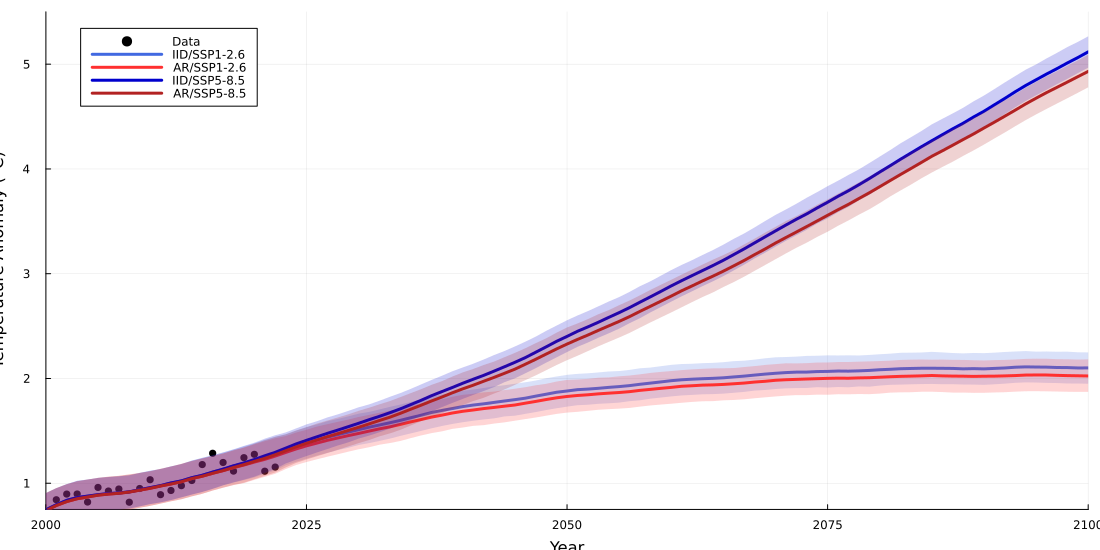

In [18]:
ebm_sim_85(params) = ebm(forcing_non_aerosol_85[sim_idx], forcing_aerosol_85[sim_idx], p = params)
ebm_sim_26(params) = ebm(forcing_non_aerosol_26[sim_idx], forcing_aerosol_26[sim_idx], p = params)

# iid residuals
y_err = zeros(length(sim_idx))
y_err[1:length(hind_idx)] = temp_sd

residuals_iid = stack(rand.(Normal.(0, sqrt.(y_err.^2 .+ θ_iid[end]^2)), n), dims=1)
model_iid_85 = ebm_sim_85(θ_iid[1:end-1])
model_iid_26 = ebm_sim_26(θ_iid[1:end-1])
model_sim_iid_85 = (residuals_iid .+ model_iid_85)'
model_sim_iid_26 = (residuals_iid .+ model_iid_26)'
q90_iid_85 = mapslices(col -> quantile(col, [0.05, 0.5, 0.95]), model_sim_iid_85; dims=1) # compute 90% prediction interval```
q90_iid_26 = mapslices(col -> quantile(col, [0.05, 0.5, 0.95]), model_sim_iid_26; dims=1) # compute 90% prediction interval```

# AR residuals
residuals_ar = zeros(length(sim_idx), n)
for t = 1:length(sim_idx)
    if t == 1
        residuals_ar[t, :] = rand(Normal(0, sqrt(θ_ar[end]^2 / (1 - θ_ar[end-1]^2 + temp_sd[1]^2))), n)
    elseif t <= length(hind_idx)
        residuals_ar[t, :] = θ_ar[end-1] * residuals_ar[t-1, :] + rand(Normal(0, sqrt(θ_ar[end]^2 + temp_sd[t]^2)), n)
    else
        residuals_ar[t, :] = θ_ar[end-1] * residuals_ar[t-1, :] + rand(Normal(0, θ_ar[end]), n)
    end
end
model_ar_85 = ebm_sim_85(θ_ar[1:end-2])
model_ar_26 = ebm_sim_26(θ_ar[1:end-2])
model_sim_ar_26 = (residuals_ar .+ model_ar_26)'
model_sim_ar_85 = (residuals_ar .+ model_ar_85)'
q90_ar_26 = mapslices(col -> quantile(col, [0.05, 0.5, 0.95]), model_sim_ar_26; dims=1) # compute 90% prediction interval
q90_ar_85 = mapslices(col -> quantile(col, [0.05, 0.5, 0.95]), model_sim_ar_85; dims=1) # compute 90% prediction interval

p_sim= scatter(time_obs, temp_obs, color=:black, label="Data", ylabel="Temperature Anomaly (°C)", xlabel="Year")
plot!(p_sim, sim_years, q90_iid_26[2, :], ribbon=(q90_iid_26[2, :] - q90_iid_26[1, :], q90_iid_26[3, :] - q90_iid_26[2, :]), fillalpha=0.2, linewidth=3, color=:royalblue, label="IID/SSP1-2.6")
plot!(p_sim, sim_years, q90_ar_26[2, :], ribbon=(q90_ar_26[2, :] - q90_ar_26[1, :], q90_ar_26[3, :] - q90_ar_26[2, :]), fillalpha=0.2, linewidth=3, color=:firebrick1, label="AR/SSP1-2.6")
plot!(p_sim, sim_years, q90_iid_85[2, :], ribbon=(q90_iid_85[2, :] - q90_iid_85[1, :], q90_iid_85[3, :] - q90_iid_85[2, :]), fillalpha=0.2, linewidth=3, color=:blue3, label="IID/SSP5-8.5")
plot!(p_sim, sim_years, q90_ar_85[2, :], ribbon=(q90_ar_85[2, :] - q90_ar_85[1, :], q90_ar_85[3, :] - q90_ar_85[2, :]), fillalpha=0.2, linewidth=3, color=:firebrick, label="AR/SSP5-8.5")
plot!(p_sim, size=(1100, 550))
xlims!((2000, 2100))
ylims!((0.75, 5.5))

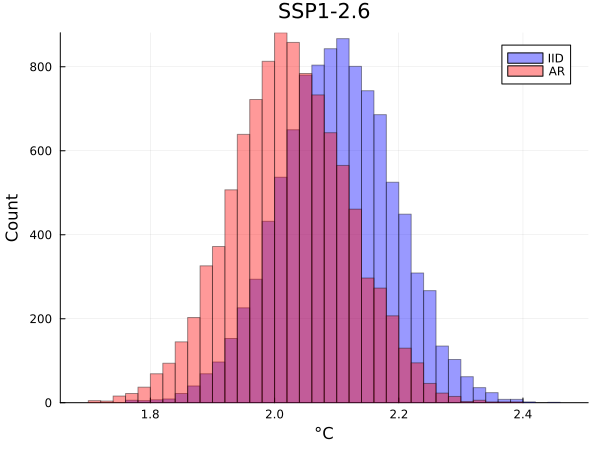

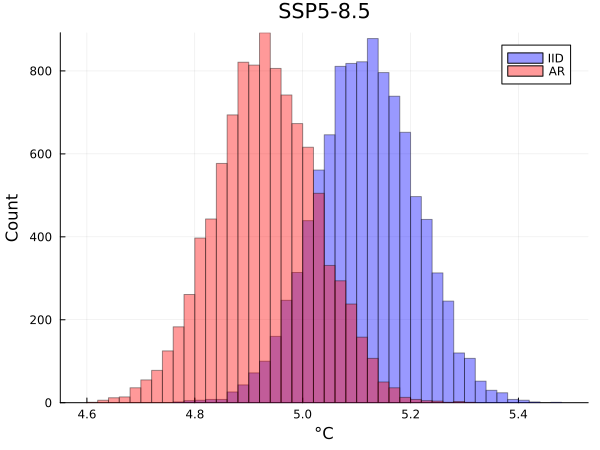

In [19]:
p1 = histogram(model_sim_iid_26[:, end], color=:blue, xlabel="°C", ylabel="Count", label="IID", size=(600, 450), alpha=0.4, title="SSP1-2.6")
histogram!(p1, model_sim_ar_26[:, end], color=:red, label="AR", alpha=0.4)
p2 = histogram(model_sim_iid_85[:, end], color=:blue, xlabel="°C", ylabel="Count", label="IID", size=(600, 450), alpha=0.4, title="SSP5-8.5")
histogram!(p2, model_sim_ar_85[:, end], color=:red, label="AR", alpha=0.4)

display(p1)
display(p2)